<a href="https://colab.research.google.com/github/charubhalla14-afk/charubhalla14-afk/blob/main/sustainable_fashion_consumption.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#For uploading dataset file to collab.
from google.colab import files
uploaded = files.upload()

Saving sustainable_fashion_consumption.csv to sustainable_fashion_consumption.csv


In [ ]:
# ==============================
# SECTION 1: IMPORTS & LOAD DATA
# ==============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)
from imblearn.over_sampling import SMOTE

# Display settings
pd.set_option('display.max_columns', None)

# Load dataset ONCE
df = pd.read_csv('sustainable_fashion_consumption.csv')

print("First 5 rows:")
display(df.head())
print("\nShape:", df.shape)

First 5 rows:


,Responses,What is your Gender?,What is your age?,What is your educational level?,What is your current occupation?,Please tick your monthly household income.,How aware are you about sustainability and eco-friendly products in general?,Sustainable apparels are manufactured using eco-friendly raw materials such as recycled and organic fabrics.,"Sustainable apparels are manufactured from natural fabric devoid of chemicals, having negligible environmental impact.",Sustainable apparels are normal clothes manufactured using basic procedures used in any other clothes manufacturing process.,"Anything that has been made from already existing materials, fabrics, metals etc.",The processes involved in the manufacturing and disposal of apparels comprise of sustainable environmental practices.,Sustainable apparels are disposed in a biodegradable manner.,Sustainable apparels are made without the use of any animal tissue product.,"Sustainable apparels are the ones that are passed on to the loved ones, to increase usability and decrease the consumption.",Sustainable apparels are made under good working conditions.,I am aware of the benefits of sustainable apparels for the environment.,I am aware on how to identify a sustainable apparel.,I am aware from where I can purchase sustainable apparels.,I am aware of various brands offering sustainable apparels,I am aware of various symbols /certifications / other identifiers which declare the apparel as sustainable or organic,Deterioration of the environment is a serious issue and sustainable apparels can contribute in saving the environment.,Sustainable apparels are true to their environment friendly claims as they are made with organic and natural fabrics.,Sustainable apparels are biodegradable and therefore its disposal is environment friendly,No animal tissue is used for making sustainable apparels and this reduces negative environmental impact.,Environment deterioration is bound to happen and sustainable apparels cannot help in protecting it.,Do you purchase sustainable apparels?,How frequently do you buy Sustainable Apparel?,I prefer sustainable apparels over non-sustainable clothes.,I would agree to pay even extra price for environment friendly products to save our environment.,Using sustainable apparels gives a sense of satisfaction,While purchasing sustainable apparels I thoroughly read label and check tag to see if they are environmentally safe.,Paying premium price for sustainable apparels is a mere wastage of money.,"Before buying sustainable apparels, I compare its price with normal apparels.",I would purchase and consume sustainable apparels if they are easily available.,Using sustainable apparels is a status symbol.,"I would prefer to buy sustainable apparels if I have enough information, which confirms their environmental benefits.",I buy sustainable apparels of the brands which I rely upon.,"While purchasing sustainable apparels, I consider specific features of the product like: its color, fabric texture, and maintenance required.",I seek the help of retail staff to explain me information regarding its contents and benefits of the sustainable apparels.,I use sustainable apparels because my friends and family use the same.,"I strongly consider the response of people about the quality of the sustainable apparel, who have already used them.",Concern for health,Concern for social status,Concern for the environment,Seeking better quality product,Being up-to-date with the latest market trends,How will you describe your level of satisfaction regarding sustainable apparels?,How would you express your willingness to recommend sustainable apparels to friends and relatives?,Lack of awareness about sustainable apparels and their environmental impact.,Sustainable apparels are very expensive.,Sustainable apparels are not promoted properly.,Lack of confidence towards the quality of sustainable apparels.,Sustainable apparels are not available in full range of variety,Sustainable apparels are not eas


Shape: (384, 55)


In [ ]:
# ======================================
# SECTION 2: CLEANING MISSING & DUPLICATES
# ======================================

print("Missing values per column BEFORE cleaning:\n")
print(df.isnull().sum())
print("\nTotal missing values:", df.isnull().sum().sum())

# Fill numeric columns with mean
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

# Fill categorical columns with mode
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Drop duplicate rows
before = len(df)
df.drop_duplicates(inplace=True)
after = len(df)

print("\nMissing values AFTER cleaning:\n")
print(df.isnull().sum())
print("\nRows before removing duplicates:", before)
print("Rows after removing duplicates:", after)
print("Final shape:", df.shape)

Missing values per column BEFORE cleaning:

Responses                                                                                                                                        0
What is your Gender?                                                                                                                             0
What is your age?                                                                                                                                0
What is your educational level?                                                                                                                  0
What is your current occupation?                                                                                                                 0
Please tick your monthly household income.                                                                                                       0
How aware are you about sustainability and eco-friendly products in genera

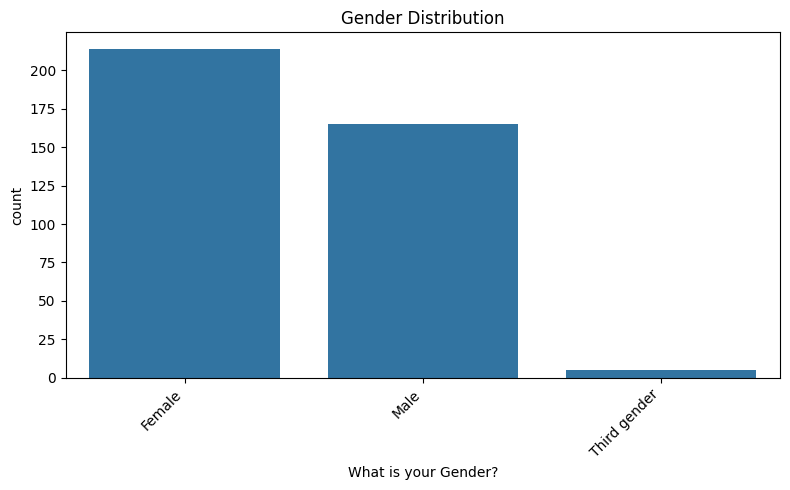

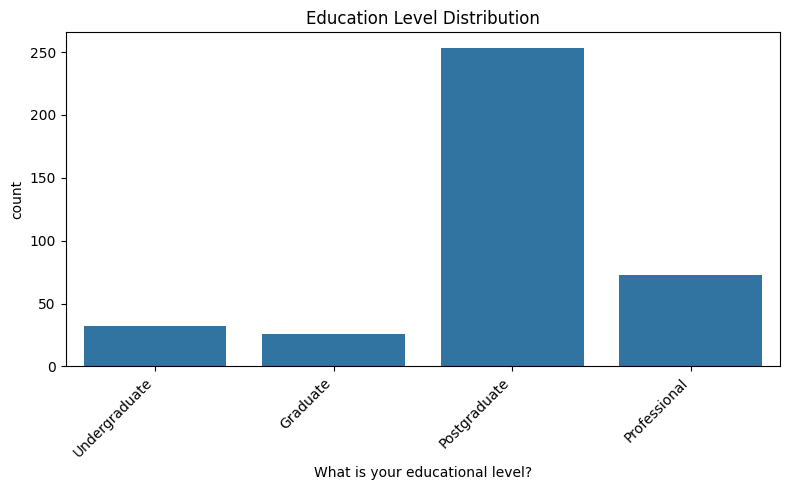

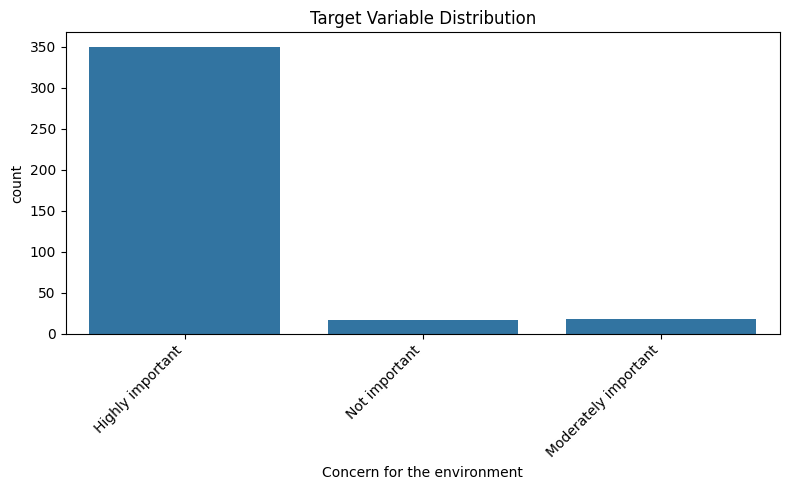

In [ ]:
# =======================
# SECTION 3: BASIC EDA
# =======================

# Use original text columns for plots
plt.figure(figsize=(8, 5))
sns.countplot(x='What is your Gender?', data=df)
plt.title('Gender Distribution')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.countplot(x='What is your educational level?', data=df)
plt.title('Education Level Distribution')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.countplot(x='Concern for the environment', data=df)
plt.title('Target Variable Distribution')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Selecting only numeric columns for correlation...
Shape of numeric_df: (384, 2)


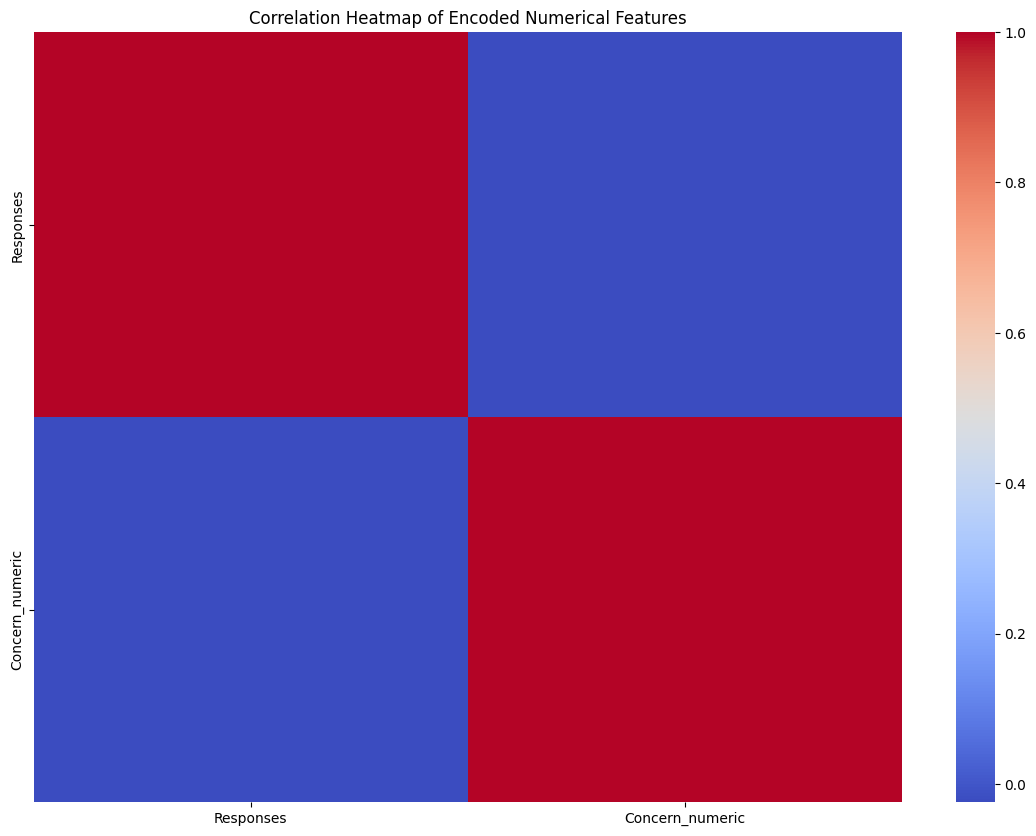

In [ ]:
# ============================================================
# SECTION 5: CORRELATION ANALYSIS
# ============================================================

print("Selecting only numeric columns for correlation...")

# Select numeric columns (this includes one-hot encoded variables and numeric features)
numeric_df = df.select_dtypes(include=['int64', 'float64'])

print("Shape of numeric_df:", numeric_df.shape)

# Compute correlation matrix
corr_matrix = numeric_df.corr()

# Plot correlation heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False)
plt.title("Correlation Heatmap of Encoded Numerical Features")
plt.show()

In [ ]:
# ======================================
# SECTION 4: CREATE NUMERIC TARGET
# ======================================

# Map text levels to numeric target (you can adjust if needed)
concern_mapping = {
    'Highly important': 2,
    'Moderately important': 1,
    'Slightly important': 0,
    'Less important': 0,
    'Not important': 0
}

df['Concern_numeric'] = df['Concern for the environment'].map(concern_mapping)

print("Unique values in Concern_numeric:", df['Concern_numeric'].unique())
print(df[['Concern for the environment', 'Concern_numeric']].head())

Unique values in Concern_numeric: [2 0 1]
  Concern for the environment  Concern_numeric
0            Highly important                2
1            Highly important                2
2            Highly important                2
3            Highly important                2
4            Highly important                2


/tmp/ipython-input-1900352909.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='What is your educational level?', y='Mean_Concern',


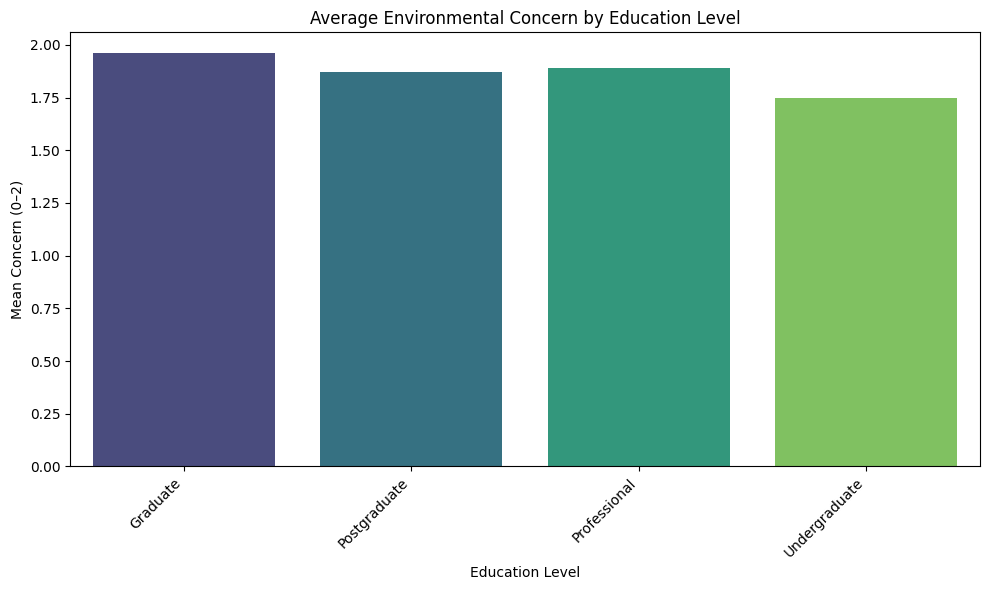

In [ ]:
# =======================================================
# SECTION 5: EDUCATION LEVEL vs ENVIRONMENTAL CONCERN
# =======================================================

mean_concern_by_education = (
    df.groupby('What is your educational level?')['Concern_numeric']
      .mean()
      .reset_index()
      .rename(columns={'Concern_numeric': 'Mean_Concern'})
)

plt.figure(figsize=(10, 6))
sns.barplot(x='What is your educational level?', y='Mean_Concern',
            data=mean_concern_by_education, palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.title('Average Environmental Concern by Education Level')
plt.ylabel('Mean Concern (0–2)')
plt.xlabel('Education Level')
plt.tight_layout()
plt.show()

In [ ]:
#Fixing column names from hidden newline characters
df.columns = df.columns.str.replace("\n", " ", regex=False).str.strip()
print(df.columns.tolist())

['Responses', 'What is your Gender?', 'What is your age?', 'What is your educational level?', 'What is your current occupation?', 'Please tick your monthly household income.', 'How aware are you about sustainability and eco-friendly products in general?', 'Sustainable apparels are manufactured using eco-friendly raw materials such as recycled and organic fabrics.', 'Sustainable apparels are manufactured from natural fabric devoid of chemicals, having negligible environmental impact.', 'Sustainable apparels are normal clothes manufactured using basic procedures used in any other clothes manufacturing process.', 'Anything that has been made from already existing materials, fabrics, metals etc.', 'The processes involved in the manufacturing and disposal of apparels comprise of sustainable environmental practices.', 'Sustainable apparels are disposed in a biodegradable manner.', 'Sustainable apparels are made without the use of any animal tissue product.', 'Sustainable apparels are the one

In [ ]:
# =========================================
# SECTION 6: DEFINE FEATURES AND TARGET
# =========================================

feature_cols = [
    'What is your Gender?',
    'What is your age?',
    'What is your educational level?',
    'Please tick your monthly household income.'
]

X = df[feature_cols]
y = df['Concern_numeric']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (384, 4)
Target shape: (384,)


In [ ]:
# =========================================
# SECTION 7: TRAIN–TEST SPLIT
# =========================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train value counts:\n", y_train.value_counts())

X_train shape: (307, 4)
X_test shape: (77, 4)
y_train value counts:
 Concern_numeric
2    280
1     14
0     13
Name: count, dtype: int64


In [ ]:
# =========================================
# SECTION 8: PREPROCESSING (ONE-HOT ENCODING)
# =========================================

categorical_features = feature_cols  # all are categorical here
numerical_features = []              # no numeric features in this subset

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

print("Fitting preprocessor on X_train...")
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed X_train shape:", X_train_processed.shape)
print("Processed X_test shape:", X_test_processed.shape)

# Get feature names for later (feature importance, etc.)
encoded_feature_names = preprocessor.get_feature_names_out()

Fitting preprocessor on X_train...
Processed X_train shape: (307, 14)
Processed X_test shape: (77, 14)


In [ ]:
# =========================================
# SECTION 9: SMOTE (HANDLE CLASS IMBALANCE)
# =========================================

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_processed, y_train)

print("Class distribution BEFORE SMOTE:", y_train.value_counts().to_dict())
print("Class distribution AFTER SMOTE:", y_train_resampled.value_counts().to_dict())
print("Resampled X_train shape:", X_train_resampled.shape)

Class distribution BEFORE SMOTE: {2: 280, 1: 14, 0: 13}
Class distribution AFTER SMOTE: {2: 280, 1: 280, 0: 280}
Resampled X_train shape: (840, 14)


🔹 Logistic Regression Accuracy: 0.5064935064935064
🔹 Logistic Regression F1 (weighted): 0.6220095693779905

Classification Report (Logistic Regression):
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.00      0.00      0.00         4
           2       0.89      0.56      0.68        70

    accuracy                           0.51        77
   macro avg       0.30      0.19      0.23        77
weighted avg       0.81      0.51      0.62        77



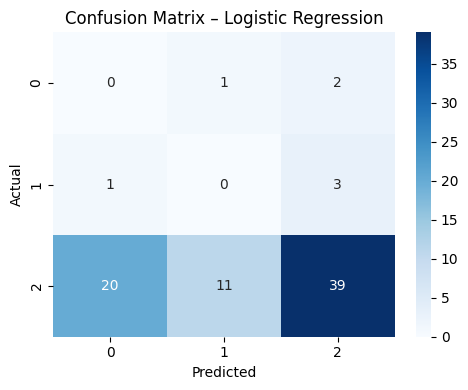

In [ ]:
# =========================================
# SECTION 10: LOGISTIC REGRESSION
# =========================================

logreg_model = LogisticRegression(max_iter=1000, random_state=42)
logreg_model.fit(X_train_resampled, y_train_resampled)

y_pred_log = logreg_model.predict(X_test_processed)

acc_log = accuracy_score(y_test, y_pred_log)
f1_log = f1_score(y_test, y_pred_log, average='weighted')

print("🔹 Logistic Regression Accuracy:", acc_log)
print("🔹 Logistic Regression F1 (weighted):", f1_log)
print("\nClassification Report (Logistic Regression):\n",
      classification_report(y_test, y_pred_log))

cm_log = confusion_matrix(y_test, y_pred_log)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix – Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

🔹 Random Forest Accuracy: 0.8571428571428571
🔹 Random Forest F1 (weighted): 0.8450704225352113

Classification Report (Random Forest):
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.00      0.00      0.00         4
           2       0.92      0.94      0.93        70

    accuracy                           0.86        77
   macro avg       0.31      0.31      0.31        77
weighted avg       0.83      0.86      0.85        77



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


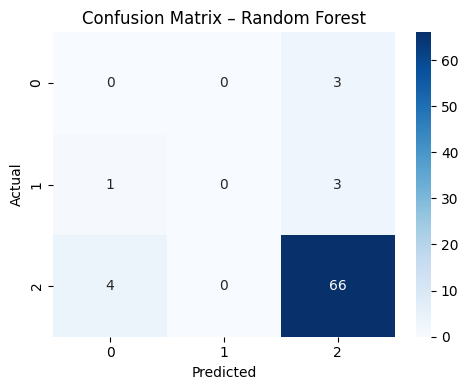


Top 10 Important Features (Random Forest):


,Feature,Importance
13,cat__Please tick your monthly household income...,0.124164
5,cat__What is your age?_35-44,0.105260
4,cat__What is your age?_25-34,0.104816
11,cat__Please tick your monthly household income...,0.094863
1,cat__What is your Gender?_Male,0.090106
12,cat__Please tick your monthly household income...,0.085969
0,cat__What is your Gender?_Female,0.082895
8,cat__What is your educational level?_Postgraduate,0.074698
9,cat__What is your educational level?_Professional,0.054542
2,cat__What is your Gender?_Third gender,0.053884


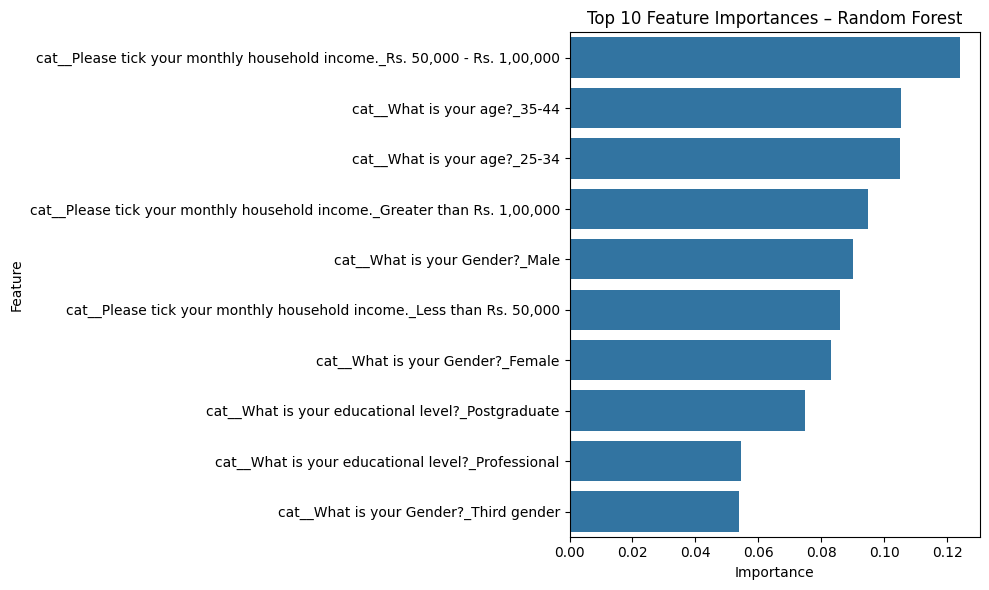

In [ ]:
# =========================================
# SECTION 11: RANDOM FOREST
# =========================================

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)
rf_model.fit(X_train_resampled, y_train_resampled)

y_pred_rf = rf_model.predict(X_test_processed)

acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf, average='weighted')

print("🔹 Random Forest Accuracy:", acc_rf)
print("🔹 Random Forest F1 (weighted):", f1_rf)
print("\nClassification Report (Random Forest):\n",
      classification_report(y_test, y_pred_rf))

cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix – Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# --- FEATURE IMPORTANCE ---
rf_importances = rf_model.feature_importances_
importance_df_rf = pd.DataFrame({
    'Feature': encoded_feature_names,
    'Importance': rf_importances
}).sort_values(by='Importance', ascending=False)

print("\nTop 10 Important Features (Random Forest):")
display(importance_df_rf.head(10))

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df_rf.head(10))
plt.title("Top 10 Feature Importances – Random Forest")
plt.tight_layout()
plt.show()

SHAP values computed successfully!


<Figure size 1000x600 with 0 Axes>

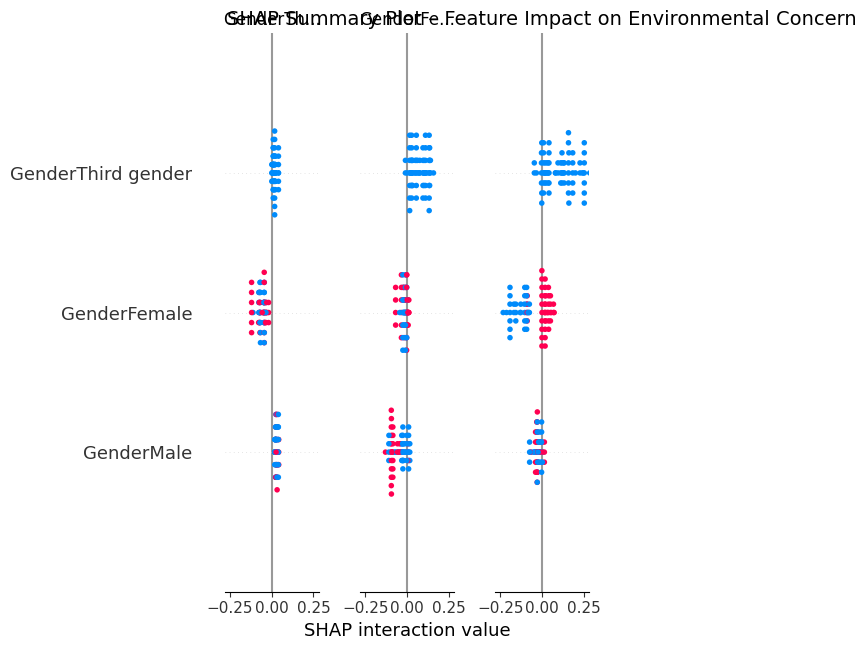

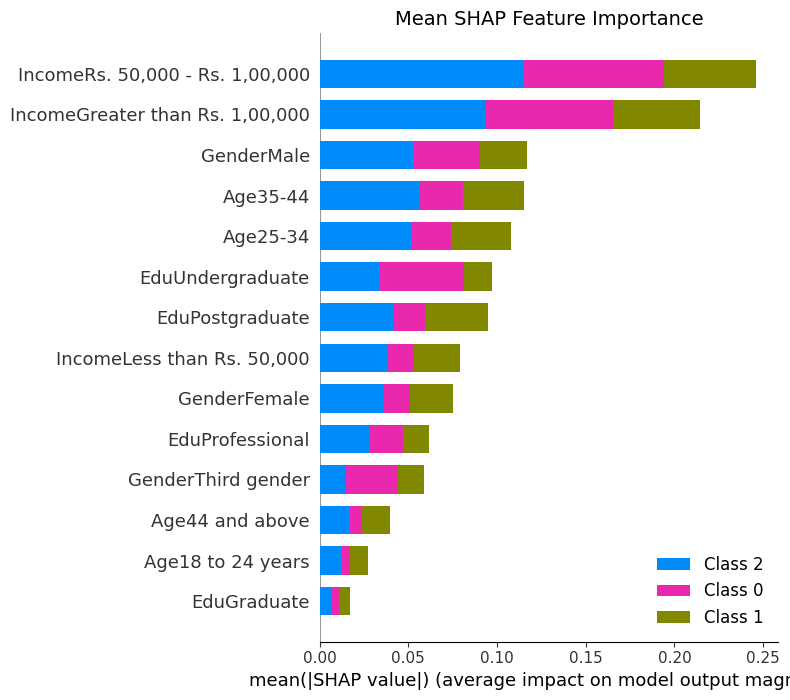

In [ ]:
# ======================================================
# 🌿 SHAP EXPLANABILITY FOR RANDOM FOREST
# ======================================================

import shap
import numpy as np
import matplotlib.pyplot as plt

# 1. Create SHAP Explainer (TreeExplainer is ideal for RF/XGBoost)
explainer = shap.TreeExplainer(rf_model)

# Convert X_test_processed to dense if it's sparse
if hasattr(X_test_processed, "toarray"):
    X_test_dense = X_test_processed.toarray()
else:
    X_test_dense = X_test_processed

# 2. Compute SHAP values
shap_values = explainer.shap_values(X_test_dense)

print("SHAP values computed successfully!")

# 3. Get cleaner feature names
raw_feature_names = preprocessor.get_feature_names_out()

clean_names = []
for name in raw_feature_names:
    name = name.replace("cat__", "") \
               .replace("num__", "") \
               .replace("What is your Gender?_", "Gender_") \
               .replace("What is your educational level?_", "Edu_") \
               .replace("Please tick your monthly household income.", "Income") \
               .replace("What is your age?", "Age") \
               .replace("_", "")
    clean_names.append(name)

# 4. SHAP Summary Plot (Beeswarm)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_dense, feature_names=clean_names, show=False)
plt.title("SHAP Summary Plot – Feature Impact on Environmental Concern", fontsize=14)
plt.tight_layout()
plt.show()

# 5. Bar Plot – Mean SHAP Importance
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_dense, feature_names=clean_names,
                  plot_type="bar", show=False)
plt.title("Mean SHAP Feature Importance", fontsize=14)
plt.tight_layout()
plt.show()

🔹 Decision Tree Accuracy: 0.6493506493506493
🔹 Decision Tree F1 (weighted): 0.7245866088370831

Classification Report (Decision Tree):
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.08      0.25      0.12         4
           2       0.91      0.70      0.79        70

    accuracy                           0.65        77
   macro avg       0.33      0.32      0.30        77
weighted avg       0.83      0.65      0.72        77



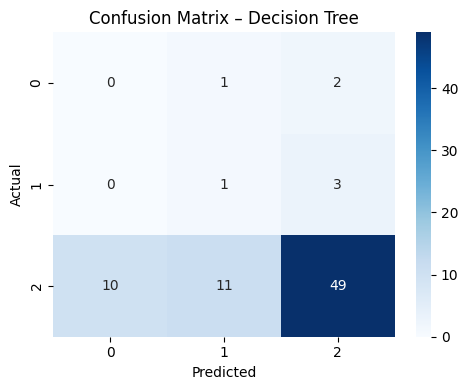

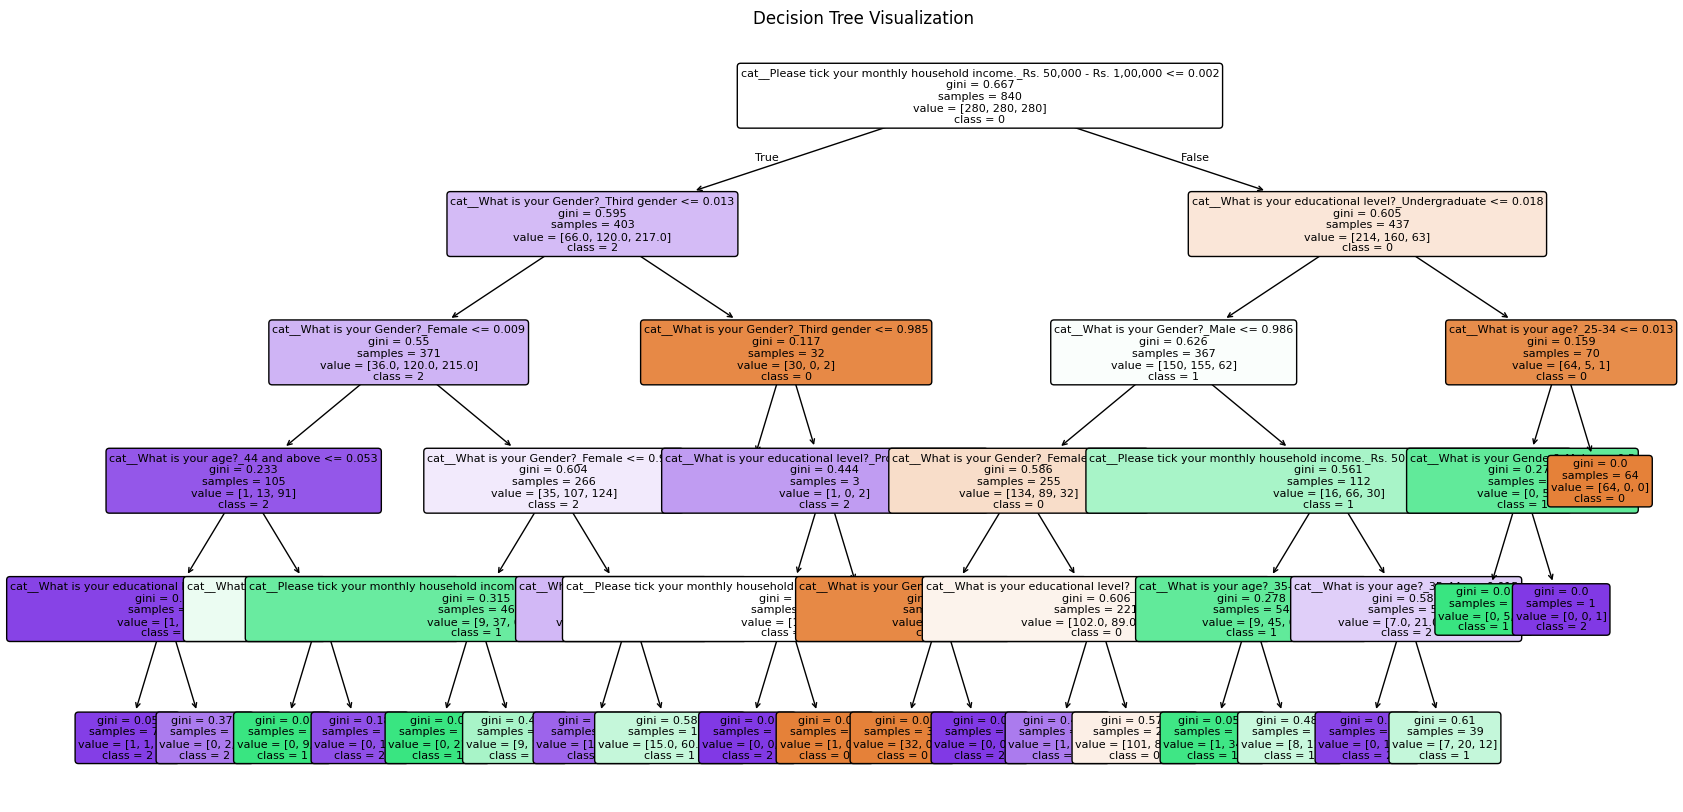

In [ ]:
# =========================================
# SECTION 12: DECISION TREE
# =========================================

dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_model.fit(X_train_resampled, y_train_resampled)

y_pred_dt = dt_model.predict(X_test_processed)

acc_dt = accuracy_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt, average='weighted')

print("🔹 Decision Tree Accuracy:", acc_dt)
print("🔹 Decision Tree F1 (weighted):", f1_dt)
print("\nClassification Report (Decision Tree):\n",
      classification_report(y_test, y_pred_dt))

cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix – Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# Optional: visualize tree (great for viva / paper)
plt.figure(figsize=(20, 10))
plot_tree(
    dt_model,
    filled=True,
    feature_names=encoded_feature_names,
    class_names=[str(c) for c in dt_model.classes_],
    rounded=True,
    fontsize=8
)
plt.title("Decision Tree Visualization")
plt.show()

Top 10 Positive Coefficients (Logistic Regression):


,Feature,Coefficient
2,cat__What is your Gender?_Third gender,1.827617
10,cat__What is your educational level?_Undergrad...,1.651456
13,cat__Please tick your monthly household income...,0.976468
6,cat__What is your age?_44 and above,0.392424
5,cat__What is your age?_35-44,0.325625
12,cat__Please tick your monthly household income...,0.225579
8,cat__What is your educational level?_Postgraduate,0.068337
4,cat__What is your age?_25-34,-0.084631
0,cat__What is your Gender?_Female,-0.606520
9,cat__What is your educational level?_Professional,-0.611482



Top 10 Negative Coefficients (Logistic Regression):


,Feature,Coefficient
5,cat__What is your age?_35-44,0.325625
12,cat__Please tick your monthly household income...,0.225579
8,cat__What is your educational level?_Postgraduate,0.068337
4,cat__What is your age?_25-34,-0.084631
0,cat__What is your Gender?_Female,-0.606520
9,cat__What is your educational level?_Professional,-0.611482
3,cat__What is your age?_18 to 24 years,-0.631816
7,cat__What is your educational level?_Graduate,-1.106709
11,cat__Please tick your monthly household income...,-1.200445
1,cat__What is your Gender?_Male,-1.219495


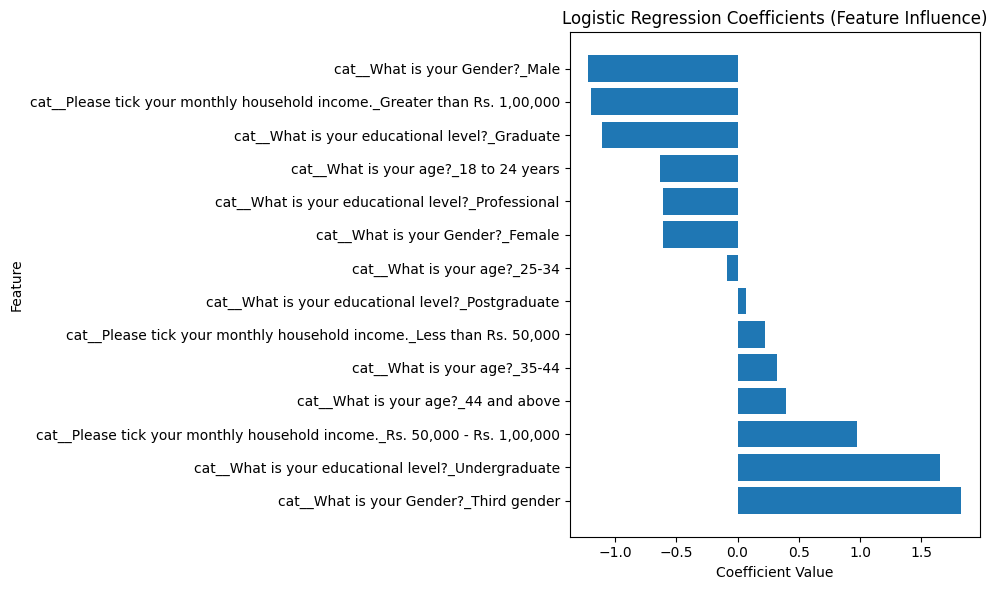

In [ ]:
# ====================================================
# SECTION 13: LOGISTIC REGRESSION – FEATURE IMPORTANCE
# ====================================================

logreg_coefs = logreg_model.coef_[0]

importance_df_log = pd.DataFrame({
    'Feature': encoded_feature_names,
    'Coefficient': logreg_coefs
}).sort_values(by='Coefficient', ascending=False)

print("Top 10 Positive Coefficients (Logistic Regression):")
display(importance_df_log.head(10))

print("\nTop 10 Negative Coefficients (Logistic Regression):")
display(importance_df_log.tail(10))

plt.figure(figsize=(10, 6))
plt.barh(importance_df_log['Feature'], importance_df_log['Coefficient'])
plt.title("Logistic Regression Coefficients (Feature Influence)")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

Accuracy (XGBoost): 0.8701298701298701

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.00      0.00      0.00         4
           2       0.91      0.96      0.93        70

    accuracy                           0.87        77
   macro avg       0.30      0.32      0.31        77
weighted avg       0.82      0.87      0.85        77



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


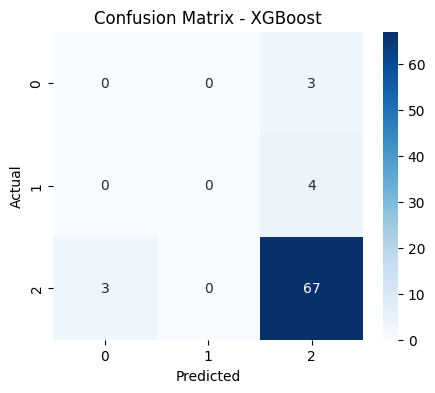

In [ ]:
# ==========================================================
# XGBOOST CLASSIFIER (ADVANCED MODEL)
# ==========================================================

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Train XGBoost on SMOTE-resampled data
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train_resampled, y_train_resampled)

# Predictions
y_pred_xgb = xgb_model.predict(X_test_processed)

# Evaluation
print("Accuracy (XGBoost):", accuracy_score(y_test, y_pred_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))

# Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

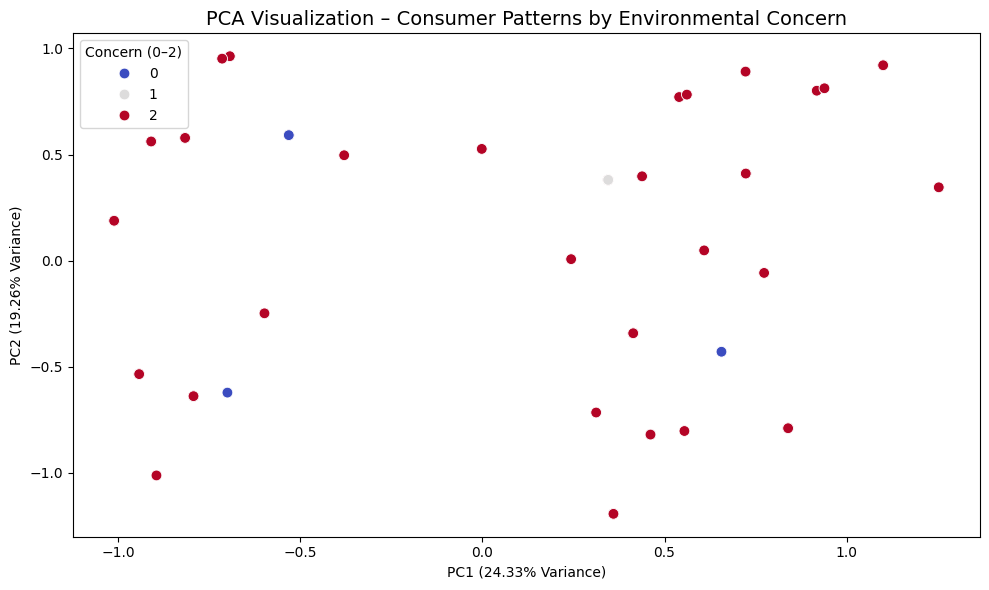

Explained variance ratio: [0.24327198 0.19258001]


In [ ]:
# ======================================================
# 🌿 PCA FOR VISUALIZING CONSUMER SEGMENT PATTERNS
# ======================================================

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# IMPORTANT:
# Use the *processed* X_test (same as used for predictions)
# Convert to dense if needed
if hasattr(X_test_processed, "toarray"):
    X_pca_input = X_test_processed.toarray()
else:
    X_pca_input = X_test_processed

# 1. Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_pca_input)

# 2. Create a DataFrame for visualization
pca_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'Concern Level': y_test.values
})

# 3. Plot PCA
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='PC1', y='PC2',
    hue='Concern Level',
    palette='coolwarm',
    data=pca_df,
    s=60
)

plt.title("PCA Visualization – Consumer Patterns by Environmental Concern", fontsize=14)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% Variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% Variance)")
plt.legend(title="Concern (0–2)")
plt.tight_layout()
plt.show()

# 4. Show explained variance
print("Explained variance ratio:", pca.explained_variance_ratio_)

In [ ]:
# Re-train all models if they are missing (safety check)
try:
    model
except:
    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_train_resampled, y_train_resampled)

try:
    rf_model
except:
    rf_model = RandomForestClassifier(random_state=42, n_estimators=200)
    rf_model.fit(X_train_resampled, y_train_resampled)

try:
    dt_model
except:
    dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)
    dt_model.fit(X_train_resampled, y_train_resampled)

In [ ]:
# Recalculate predictions for all models

y_pred = model.predict(X_test_processed)              # Logistic Regression
y_pred_rf = rf_model.predict(X_test_processed)        # Random Forest
y_pred_dt = dt_model.predict(X_test_processed)        # Decision Tree
y_pred_xgb = xgb_model.predict(X_test_processed)      # XGBoost

In [ ]:
# ======================================================
# 🌿 MODEL ACCURACY COMPARISON
# ======================================================

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

results = {
    "Model": ["Logistic Regression", "Random Forest", "Decision Tree", "XGBoost"],

    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_xgb)
    ],

    "Precision": [
        precision_score(y_test, y_pred, average='weighted'),
        precision_score(y_test, y_pred_rf, average='weighted'),
        precision_score(y_test, y_pred_dt, average='weighted'),
        precision_score(y_test, y_pred_xgb, average='weighted')
    ],

    "Recall": [
        recall_score(y_test, y_pred, average='weighted'),
        recall_score(y_test, y_pred_rf, average='weighted'),
        recall_score(y_test, y_pred_dt, average='weighted'),
        recall_score(y_test, y_pred_xgb, average='weighted')
    ],

    "F1 Score": [
        f1_score(y_test, y_pred, average='weighted'),
        f1_score(y_test, y_pred_rf, average='weighted'),
        f1_score(y_test, y_pred_dt, average='weighted'),
        f1_score(y_test, y_pred_xgb, average='weighted')
    ]
}

comparison_df = pd.DataFrame(results)
comparison_df

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.506494,0.805785,0.506494,0.622010
1,Random Forest,0.857143,0.833333,0.857143,0.845070
2,Decision Tree,0.649351,0.828912,0.649351,0.724587
3,XGBoost,0.870130,0.823096,0.870130,0.845960


/tmp/ipython-input-2549541599.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y="Accuracy", data=comparison_df, palette="viridis")


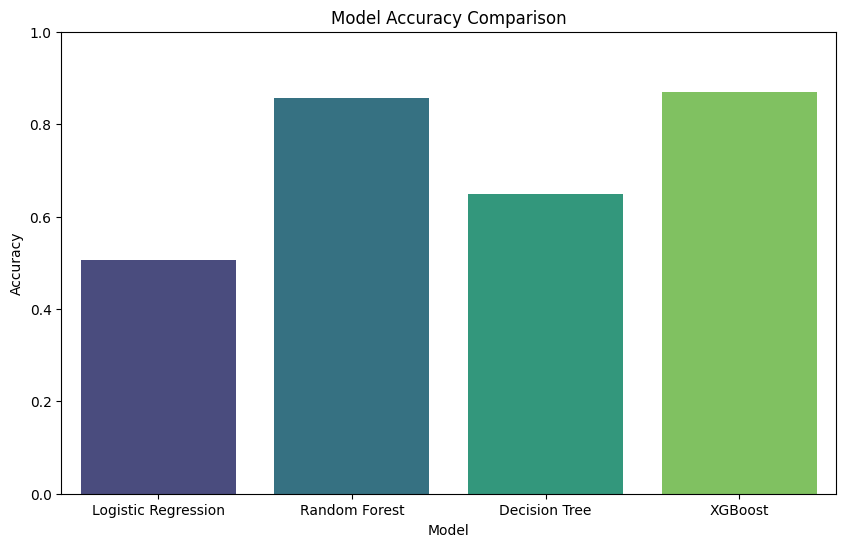

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(x="Model", y="Accuracy", data=comparison_df, palette="viridis")
plt.title("Model Accuracy Comparison")
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.show()